In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)
df_hourly = elec

# Insert filter for waking hours and calculate offsets
df_hourly["hour"] = df_hourly["timestamp"].dt.hour
df_hourly['awake'] = ((df_hourly['hour'] >= 6) & (df_hourly['hour'] <= 23)).astype(int)
df_hourly["kwh_lag1"] = df_hourly["kwh"].shift(1)
df_hourly["kwh_lag2"] = df_hourly["kwh"].shift(2)
df_hourly["kwh_lag3"] = df_hourly["kwh"].shift(3)

# Resample to daily
df_daily = (
    df_hourly.set_index("timestamp")
    .resample("D")
    .agg(
        kwh=("kwh", "sum"),
    )
    .reset_index()
)
df_daily["kwh_lag1"] = df_daily["kwh"].shift(1)
df_daily["kwh_lag2"] = df_daily["kwh"].shift(2)
df_daily["kwh_lag3"] = df_daily["kwh"].shift(3)

# Drop Nones for both datasets
df_hourly = df_hourly.dropna(axis=0)
df_daily = df_daily.dropna(axis=0)


In [28]:
OVERNIGHT_ONLY = False

if OVERNIGHT_ONLY:
    df_hourly = df_hourly[df_hourly["awake"] == 0]

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# AR(1H) - predict this hour from previous hour
X = df_hourly[['kwh_lag1']].values
y = df_hourly['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(1H) R²: {r2:.3f}")
print(f"AR(1H) RMSE: {rmse:.2f}")

# AR(2H) - predict this hour from previous hour
X = df_hourly[['kwh_lag1','kwh_lag2']].values
y = df_hourly['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(2H) R²: {r2:.3f}")
print(f"AR(2H) RMSE: {rmse:.2f}")

# AR(3H) - predict this hour from previous hour
X = df_hourly[['kwh_lag1','kwh_lag2', 'kwh_lag3']].values
y = df_hourly['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(3H) R²: {r2:.3f}")
print(f"AR(3H) RMSE: {rmse:.2f}")

AR(1H) R²: 0.584
AR(1H) RMSE: 0.90
AR(2H) R²: 0.607
AR(2H) RMSE: 0.87
AR(3H) R²: 0.616
AR(3H) RMSE: 0.86


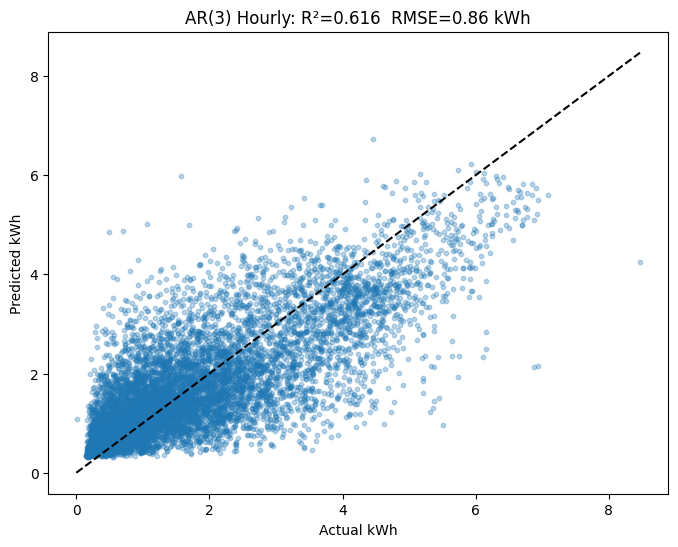

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'AR(3) Hourly: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()

In [31]:
# AR(1D) - predict this day from previous day
X = df_daily[['kwh_lag1']].values
y = df_daily['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(1D) R²: {r2:.3f}")
print(f"AR(1D) RMSE: {rmse:.2f}")

# AR(2D) - predict this day from previous day
X = df_daily[['kwh_lag1', 'kwh_lag2']].values
y = df_daily['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(2D) R²: {r2:.3f}")
print(f"AR(2D) RMSE: {rmse:.2f}")

# AR(3D) - predict this day from previous day
X = df_daily[['kwh_lag1', 'kwh_lag2', 'kwh_lag3']].values
y = df_daily['kwh'].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

pred = ar_model.predict(X_test)
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"AR(3D) R²: {r2:.3f}")
print(f"AR(3D) RMSE: {rmse:.2f}")

AR(1D) R²: 0.731
AR(1D) RMSE: 12.42
AR(2D) R²: 0.736
AR(2D) RMSE: 12.32
AR(3D) R²: 0.745
AR(3D) RMSE: 12.11


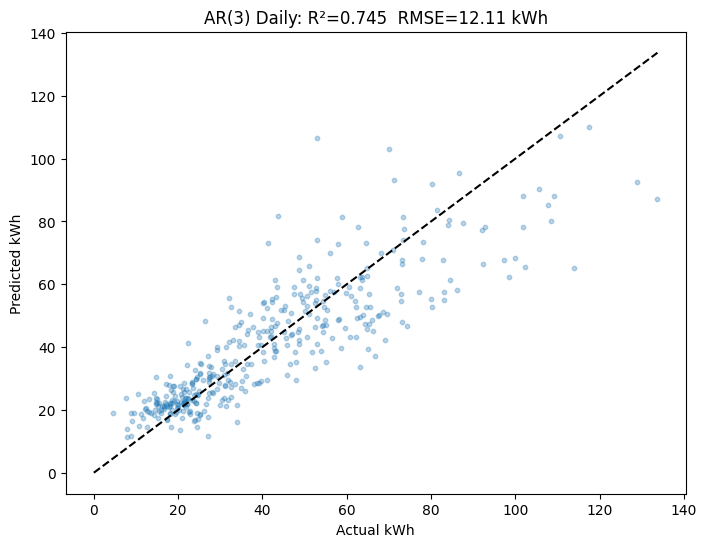

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'AR(3) Daily: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()